# Intro to SageMath

## Nadia Lafrenière
### Concordia University

## SageDays 130.5: SageMath festival
### ETS, April 28, 2026

# What is Sage?

<img style="float: right;" src="images/sage-logo.svg" width="150">

- SAGE = System for Algebra and Geometry Experimentation
- Open-source mathematical software
- Works for all areas of math
- Written in Python. Sage and Python have the same syntax.
- Includes many existing software, from R (statistics) to Gap (group theory), PARI (number theory) to Maxima (symbolic computations). And of course, the Jupyter notebook

# Open-source?

Open-source software must have four freedoms:
- Freedom to use (for free)
- Freedom to inspect how the program is built $\implies$ source code is available
- Freedom to redistribute
- Freedom to modify, then redistribute $\implies$ source code is available, we can contribute

# The art of not reinventing the wheel

- Many open-source mathematical software existed before Sage

<table><tr>
<td> <img src="images/Maximalogo.png" width="100"></td> <td> <img src="images/PARI.svg" width="100"/> </td> <td> <img src="images/R_logo.svg" width="100"></td> <td> <img src="images/GAPlogo.png" width="100"/></td>
</tr></table>

- Over 100 components (pre-existing software) are now in Sage, and included with its installation.

- These libraries, softwares and databases are often very good and extensively used.

- Sage can even serve as a repository for knowledge

- Sage interfaces with common mathematical databases

# Python

<img style="float: right;" src="images/Python-logo.svg">

 - General purpose programming language
 - Now ranked as the most popular programming language
 - Simple syntax, oriented-object and functional paradigms
 - Sage uses Python, and adds math functions to it

# A community

- SageMath Days
- Virtual community: Volunteer developers from around the world
- Channels to ask for help: Zulip, ask.sagemath.org, ...

# Basics of SageMath

- Most basic usage: powerful graphing calculator
- More interesting usage: SageMath for teaching (and to doing homework)
- More advanced usage: SageMath for mathematical exploration and discovery
- Most fun usage: SageMath for recreation!

# SageMath as a powerful (graphing) calculator

* SageMath can perform all the computations you would do in a regular calculator.
* It can draw the graph of a function (of one or several variables, and vector fields).
* It can solve systems of equations, either through matrices, or using the function `solve`.
* It can solve your calculus problems.

## Drawing with SageMath

SageMath can be used as a graphing calculator.

Before you draw, ask yourself:
* What is the dimension of the space that my object lives in (2d/3d)?
* What are your variables (you need to declare them all except `x`)?
* How is the equation given? As an explicit equation in cartesian coordinates ($y=f(x)$, `plot`), as an implicit equation (`implicit_plot`), as an equation in polar coordinates ($r = f(\theta)$, `polar_plot`), as a parametric equation ($\vec{r}(t) = \langle x(t), y(t) \rangle$, `parametric_plot`) or as a vector field (`plot_vector_field`)? 
* Look at your output! Does it look like what you expected?

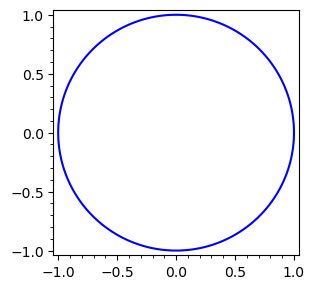

In [1]:
var('y')
show(implicit_plot(x^2+y^2==1, (-1,1), (-1,1), figsize=4))
#show(implicit_plot3d(x^2+y^2==1, (-1,1), (-1,1), (-1,1)), figsize=4)

In [2]:
var('y')
#show(implicit_plot(x^2+y^2==1, (-1,1), (-1,1), figsize=4))
show(implicit_plot3d(x^2+y^2==1, (-1,1), (-1,1), (-1,1)), figsize=4)

Graphics3d Object

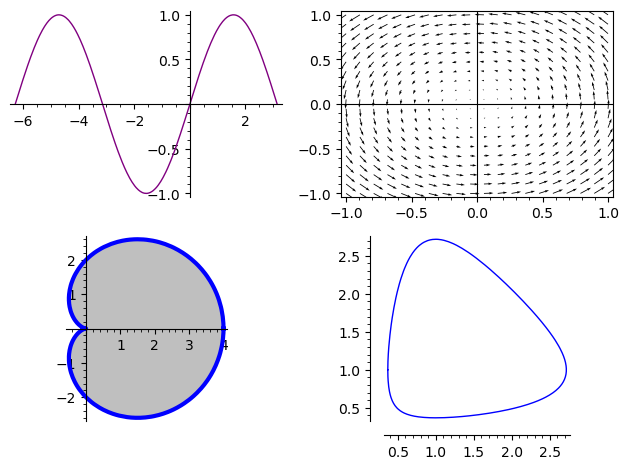

In [3]:
var('t')
graphics_array([[plot(sin(x), (-2*pi, pi), color='purple'),
                plot_vector_field((-y,x), (-1,1), (-1,1))],
                [polar_plot(2 + 2*cos(x), (x, 0, 2*pi), thickness=3, fill=True),
                parametric_plot((e^cos(t), e^sin(t)), (t, -pi, pi))]])

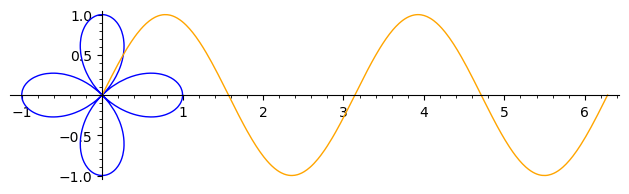

In [4]:
# We can put plots on the same picture
polar_plot(cos(2*x), (x, 0, 2*pi)) +\
plot(sin(2*x), 0, 2*pi, color = 'orange')

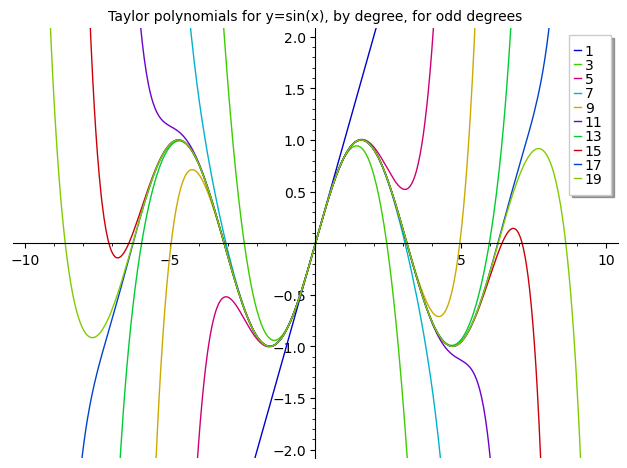

In [5]:
plot([taylor(sin(x), x, 0, n) for n in range(1,20,2)],\
     xmin=-10, xmax=10, ymin=-2, ymax=2, legend_label=list(range(1,20,2)),\
     title="Taylor polynomials for y=sin(x), by degree, for odd degrees")

In [6]:
parametric_plot3d((sin(t), cos(t), t), (t, -2*pi, 2*pi), thickness=2)

Graphics3d Object

In [7]:
# A surface along with its tangent plane at a given point
f(x,y) = x^2+y^2-25
paraboloid = plot3d(f(x,y), [-4,4], [-4,4], opacity=0.3, mesh=True)
pt = (2*sqrt(2), 2*sqrt(2))
slope = f.gradient().subs(x==pt[0]).subs(y==pt[1])
TP1(x,y) = f.subs(x==pt[0], y==pt[1]) + slope[0]*(x-pt[0]) + slope[1]*(y-pt[1])
plot3d(TP1(x,y), (1,4), (1,4), color='aqua', opacity=0.7) + \
paraboloid + \
point((pt[0], pt[1], f.subs(x==pt[0], y==pt[1])), size=500, color='pink')

Graphics3d Object

## Solving systems of equations

SageMath can solve systems of equations (or even differential equations). For this:
- Make sure to declare all your variables (except $x$).
- The function `solve` works in general to solve one equation or multiple equations at once, but can be glitchy at times: check the outputs. Also, `solve` can be slow.
- Use `desolve` to solve differential equations.
- Matrices are a powerful tool to solve linear systems of equations.
- The function `solve` does not support inequalities (if you are interested, use linear programming instead).

In [8]:
var('y')
solve([x^2+y^2 == 1, x+y==0])  # where all these equations are true

[[x == -1/2*sqrt(2), y == 1/2*sqrt(2)], [x == 1/2*sqrt(2), y == -1/2*sqrt(2)]]

In [9]:
solve(x+2)  # if no equality is given, then it is assumed to be equal to 0

[x == -2]

The result can have multiple variables, and we don't need to solve for all of them at once.

In [10]:
# Solving this for three variables introduces new variables r1 and r2, the parameters.
var('x,y,z')
solve([x^2+y^2+z^2==1, 2*x+3*y+4*z==0])

[[x == r1,
  y == -6/25*r1 - 4/25*sqrt(-29*r1^2 + 25),
  z == -8/25*r1 + 3/25*sqrt(-29*r1^2 + 25)],
 [x == r2,
  y == -6/25*r2 + 4/25*sqrt(-29*r2^2 + 25),
  z == -8/25*r2 - 3/25*sqrt(-29*r2^2 + 25)]]

In [11]:
r1  # One would need a workaround to work with the variable r1, as it is not declared

NameError: name 'r1' is not defined

In [12]:
# Solving w.r.t. y and z, so x is the parameter
var('x,y,z')
solve([x^2+y^2+z^2==1, 2*x+3*y+4*z==0], y,z)

[[y == -6/25*x - 4/25*sqrt(-29*x^2 + 25),
  z == -8/25*x + 3/25*sqrt(-29*x^2 + 25)],
 [y == -6/25*x + 4/25*sqrt(-29*x^2 + 25),
  z == -8/25*x - 3/25*sqrt(-29*x^2 + 25)]]

In [13]:
# Solving differential equations require the call of `desolve`

y = function('y')(x)  # Don't declare it as a variable, as it is dependent!
desolve(diff(y,x,x) + 2*diff(y,x) + 10*y == 0, y)

(_K2*cos(3*x) + _K1*sin(3*x))*e^(-x)

Similarly, one can solve a system of linear equations, such as the following one:
$$ \begin{align} 
7z_0 + 2z_1 + z_2 - z_3 - z_4 &= -1 \\
z_0 - 7z_1 - 4z_2 + 6z_3 + z_4 &= 3 \\
2z_0 + 2z_1 + 3z_2 - 4z_3 - 3z_4 &= 10 \\
-2z_0 + 3z_1 + 8z_2 + 9z_3 - 2z_4 &= 6 \\
3z_0 - 2z_1 - 6z_2 - 9z_3 + 3z_4 &= -4 \end{align} .$$

In [1]:
z = SR.var('z',5); print(z)  # A tuple of variables in the symbolic ring
solution = solve([7*z[0]+2*z[1]+z[2]-z[3]-z[4]==-1,
                  z[0]-7*z[1]-4*z[2]+6*z[3]+z[4]==3,
                  2*z[0]+2*z[1]+3*z[2]-4*z[3]-3*z[4]==10,
                  -2*z[0]+3*z[1]+8*z[2]+9*z[3]-2*z[4]==6,
                  3*z[0]-2*z[1]-6*z[2]-9*z[3]+3*z[4]==-4],z)
solution

(z0, z1, z2, z3, z4)


[[z0 == (5/78),
  z1 == (-85/26),
  z2 == (119/39),
  z3 == (-89/78),
  z4 == (-35/39)]]

Alternatively, this is the solution to the following matrix system:
$$\left(\begin{array}{rrrrr}
7 & 2 & 1 & -1 & -1 \\
1 & -7 & -4 & 6 & 1 \\
2 & 2 & 3 & -4 & -3 \\
-2 & 3 & 8 & 9 & -2 \\
3 & -2 & -6 & -9 & 3
\end{array}\right)\cdot
\left(\begin{array}{r}z_1\\z_2\\z_3\\z_4\\z_5\end{array}\right)
= \left(\begin{array}{r}-1\\3\\10\\6\\-4\end{array}\right)$$

In [16]:
M = Matrix([[7,2,1,-1,-1],
            [1,-7,-4,6,1],
            [2,2,3,-4,-3],
            [-2,3,8,9,-2],
            [3,-2,-6,-9,3]])
v = vector([-1,3,10,6,-4])
M.inverse()*v

(5/78, -85/26, 119/39, -89/78, -35/39)

In [17]:
# How I generated the latex above
latex(M)

\left(\begin{array}{rrrrr}
7 & 2 & 1 & -1 & -1 \\
1 & -7 & -4 & 6 & 1 \\
2 & 2 & 3 & -4 & -3 \\
-2 & 3 & 8 & 9 & -2 \\
3 & -2 & -6 & -9 & 3
\end{array}\right)

## A calculus problem example

Consider the function $f(x) = \sin(x)+\sin(3x)+\sin(5x)$. Find all its minima, maxima and roots on $[0,\pi]$.

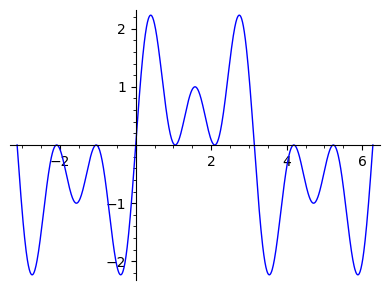

In [18]:
f(x) = sin(x)+sin(3*x)+sin(5*x)
plot(f, -pi, 2*pi, figsize=4)

In [19]:
# Finding roots
solve(f==0)  # Uh oh!

[sin(5*x) == -sin(3*x) - sin(x)]

In [20]:
# Alternatively, we can rewrite f in terms of sin(x) and cos(x)
g = f.simplify_full()  # or simplify_trig()
g

(16*cos(x)^4 - 8*cos(x)^2 + 1)*sin(x)

In [21]:
solve(g==0)  # Still not satisfying
# There should be solutions to (16*cos(x)^4 - 8*cos(x)^2 + 1)=0

[x == 0]

In [22]:
f.find_root(0,pi)  # only finds one root on the interval [0, pi]

0.0

In [23]:
# 3c, numerical approach using find_root
def find_all_roots(f, low, high, tol=0.01):
    """
    Find all roots of f on the interval (low, high).
    Won't find two roots if they are less than 'tol' (default=0.01) apart.

    Answers are given numerically.
    """
    if high-low < tol:
        print('interval is too short')
    else:
        try:  # Optional, use exceptions to have a long error message.
            root = f.find_root(low, high)
            print("Found root:", numerical_approx(root, digits=4))
            find_all_roots(f, low, root-tol)
            find_all_roots(f, root+tol, high)
        except RuntimeError:
            print("There seems to be no root on interval", (low, high))

find_all_roots(f, -0.01, pi+0.01)

Found root: 3.142
Found root: 4.259e-14
interval is too short
Found root: 2.094
Found root: 1.047
There seems to be no root on interval (0.0100000000000426, 1.037197548757765)
There seems to be no root on interval (1.057197548757765, 2.08439510085562)
There seems to be no root on interval (2.10439510085562, 3.13159265358979)
interval is too short


The roots are 4.259e-14, 1.047, 2.094, 3.142.

Notice that, when they get the numerical answer $4.259\times 10^{-14}$, it probably means $0$.

In [24]:
# We find the derivative and its roots
df = diff(f,x)
# We find the maxima using the picture. Note that the maxima occur only at
# values of x for which df(x)=0.
print(find_root(df, 0.1, 1))  # Make sure to exclude the roots
print(find_root(df, 1.1, 2))
print(find_root(df, 2.1,3))

0.3976994150920718
1.5707963267948126
2.7438932384977215


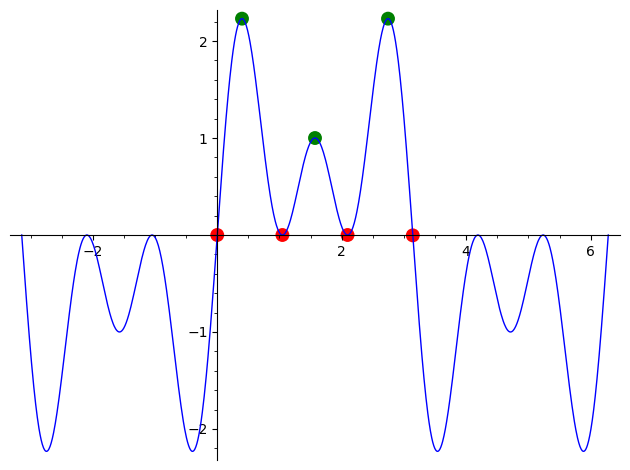

In [25]:
maxima = [0.3976994150920718, 1.5707963267948126, 2.7438932384977215]
roots = [1.047, 2.094, 3.142, 0]
plot(f, -pi, 2*pi) + points([
    (m,f(m)) for m in maxima], color='green', size=100) + points([
    (r,f(r)) for r in roots], color='red', size=100)

# SageMath for teaching

SageMath can help you for tasks related to teaching, such as
- Generating examples
- Checking exams solutions
- Creating pictures and LaTeX code

## Example: Sage for teaching linear algebra

I wanted a $4\times4$ matrix with two distinct eigenvalues, each of algebraic multiplicity $2$, and one with geometric multiplicity $1$ and one with geometric multiplicity $2$. I want nice eigenvectors.

One way to do this is to start with the Jordan form, and the eigenvectors.

In [26]:
J = Matrix([[2,1,0,0],
            [0,2,0,0],
            [0,0,3,0],
            [0,0,0,3]])  # Jordan form
S = Matrix([[1,1,0,0],
            [1,0,1,0],
            [1,0,0,0],
            [0,0,0,1]]).transpose()  # first, third and fourth columns of S are eigenvectors
M = S*J*S.inverse(); show(M)
M.eigenvectors_right()

[ 3 -1  0  0]
[ 0  2  1  0]
[ 0  0  2  0]
[ 0  0  0  3]

[(3, [(1, 0, 0, 0), (0, 0, 0, 1)], 2), (2, [(1, 1, 0, 0)], 2)]

This means that $3$ is an eigenvalue with eigenvectors $(1,0,0,0)$ and $(0,0,0,1)$, and that $2$ is an eigenvalue with algebraic multiplicity $2$ and whose all eigenvectors are scalar multiples of $(1,1,0,0)$.

### A few notes on matrix construction
- There are shortcut for defining a few matrices, such as diagonal, elementary and block diagonal ones. Type `matrix.` and hit tab to see the options.
- Many operations can be done on any matrix, without knowing the base field, such as matrix multiplication or computing the determinant.
However, some operations are sensitive to the field.

In [27]:
M = Matrix(2,2, (0,-1,1,0))
M.is_diagonalizable()

ValueError: matrix entries must be from a field

In [28]:
M1 = Matrix(QQ, 2,2, (0,-1,1,0))
M2 = Matrix(QQbar, 2,2, (0,-1,1,0))
print("Over Q, is the matrix diagonalizable:", M1.is_diagonalizable(), '\n',
      "Over the algebraic field, is the matrix diagonalizable:", M2.is_diagonalizable())

Over Q, is the matrix diagonalizable: False 
 Over the algebraic field, is the matrix diagonalizable: True


In [29]:
show(M2.diagonalization())

(
[-1*I    0]  [   1    1]
[   0  1*I], [ 1*I -1*I]
)



## Generating Latex code

One can even generate code for tikz pictures, but the code is sometimes too long for what it really needs.

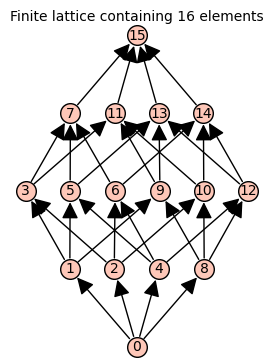

In [30]:
show(posets.BooleanLattice(4), figsize=5)

In [31]:
latex(posets.BooleanLattice(4))

\begin{tikzpicture}
\definecolor{cv0}{rgb}{0.0,0.0,0.0}
\definecolor{cfv0}{rgb}{1.0,1.0,1.0}
\definecolor{clv0}{rgb}{0.0,0.0,0.0}
\definecolor{cv1}{rgb}{0.0,0.0,0.0}
\definecolor{cfv1}{rgb}{1.0,1.0,1.0}
\definecolor{clv1}{rgb}{0.0,0.0,0.0}
\definecolor{cv2}{rgb}{0.0,0.0,0.0}
\definecolor{cfv2}{rgb}{1.0,1.0,1.0}
\definecolor{clv2}{rgb}{0.0,0.0,0.0}
\definecolor{cv3}{rgb}{0.0,0.0,0.0}
\definecolor{cfv3}{rgb}{1.0,1.0,1.0}
\definecolor{clv3}{rgb}{0.0,0.0,0.0}
\definecolor{cv4}{rgb}{0.0,0.0,0.0}
\definecolor{cfv4}{rgb}{1.0,1.0,1.0}
\definecolor{clv4}{rgb}{0.0,0.0,0.0}
\definecolor{cv5}{rgb}{0.0,0.0,0.0}
\definecolor{cfv5}{rgb}{1.0,1.0,1.0}
\definecolor{clv5}{rgb}{0.0,0.0,0.0}
\definecolor{cv6}{rgb}{0.0,0.0,0.0}
\definecolor{cfv6}{rgb}{1.0,1.0,1.0}
\definecolor{clv6}{rgb}{0.0,0.0,0.0}
\definecolor{cv7}{rgb}{0.0,0.0,0.0}
\definecolor{cfv7}{rgb}{1.0,1.0,1.0}
\definecolor{clv7}{rgb}{0.0,0.0,0.0}
\definecolor{cv8}{rgb}{0.0,0.0,0.0}
\definecolor{cfv8}{rgb}{1.0,1.0,1.0}
\definecolor{clv8}{rgb}{0.0

## Further examples in the exercises
- Sage for teaching calculus and linear algebra: The principal axes theorem.
- Sage for teaching calculus: surfaces and their intersections.

# SageMath for mathematical exploration and discovery

- SageMath is largely used as a software for mathematical research.
- We'll get talks and posters about it next week!


## SageMath for mathematical discovery in the exercises
- Mountain ranges, increasing tables and finding bijections using existing databases.

# SageMath for recreation

It all started when I was designing a quiz about graphs...

<img src="images/Africa_graph.png" width="750"/>

I was intrigued...

In [32]:
graphs.AfricaMap().edges()[:7]  # List a few edges to understand 

[('Algeria', 'Libya', None),
 ('Algeria', 'Mali', None),
 ('Algeria', 'Niger', None),
 ('Algeria', 'Mauritania', None),
 ('Algeria', 'Morocco', None),
 ('Algeria', 'Tunisia', None),
 ('Angola', 'Republic of the Congo', None)]

SageMath also has a graph called WorldMap

In [33]:
G = graphs.WorldMap()
G.neighbors('France')

['Italy',
 'Suriname',
 'Belgium',
 'Luxembourg',
 'Switzerland',
 'Brazil',
 'Monaco',
 'Germany',
 'Andorra',
 'Spain']

# Four color theorem


### Theorem: Any planar map is colorable with at most four colors.

<img src="images/World_map_with_four_colours.png" width="750"/>
Image credit: Fibonacci on Wikimedia Commons

*Note that the theorem assumes that the regions are not disconnected (such as the United States and Alaska.*

#### Challenge: make it so that the oceans (and other bodies of water) are all the same color, yet all adjacent countries are the same color. So oceans count as one color.
* Modify the graph to add a country (named 'water' or 'oceans').
* Add an edge between every country and the water. Then delete that edge for all landlocked countries.
* You may want to add an edge between water and countries that are adjacent to a large body of water, such as the Caspian Sea and the Black Sea.
* Use SageMath to find a proper coloring of the graph (i.e. a coloring in which no two adjacent countries (including water) are of the same color.
* Input the result in some map coloring software (such as mapchart.net), because the display in SageMath is not pretty.

In [34]:
# Create the classes of colors
G.coloring()

[['Afghanistan',
  'Kyrgyzstan',
  'Russia',
  'Armenia',
  'India',
  'Laos',
  'Iraq',
  'Israel',
  'Hong Kong',
  'Macau',
  'Greece',
  'Kosovo',
  'Bosnia and Herzegovina',
  'Romania',
  'Slovakia',
  'Germany',
  'Italy',
  'Liechtenstein',
  'Sudan',
  'Niger',
  'Tunisia',
  'Togo',
  'Cameroon',
  'Angola',
  "Cote d'Ivoire",
  'Senegal',
  'Djibouti',
  'Sierra Leone',
  'Western Sahara',
  'Rwanda',
  'Mozambique',
  'Botswana',
  'Spain',
  'Bolivia',
  'Uruguay',
  'Colombia',
  'Suriname',
  'Sweden',
  'Malaysia',
  'South Korea',
  'Costa Rica',
  'Honduras',
  'Belize',
  'United States',
  'Monaco',
  'Papua New Guinea',
  'Timor-Leste',
  'Lesotho',
  'Oman',
  'Qatar',
  'Cyprus',
  'Dominican Republic',
  'Ireland',
  'Saint Martin',
  'American Samoa',
  'Anguilla',
  'Antarctica',
  'Antigua and Barbuda',
  'Aruba',
  'Ashmore and Cartier Islands',
  'Australia',
  'Bahamas, The',
  'Bahrain',
  'Barbados',
  'Bermuda',
  'Bouvet Island',
  'British Indian Ocea

The output:

<img src="images/4couleurs.png" width="750"/>

# Before you go...

Help with SageMath:
-  Finding the name of a function: Type a few letters, then use **Tab completion**.
-  Remember names are **case-sensitive**: Upper case is for constructors, lower case for libraries.
-  Enter the name of the function, and add a question mark. This displays the **documentation**. Example: `number of partitions?`
-  Enter the name of the function, and add two question marks. This displays the **source code**. Example: `number of partitions??`

# More ways to find information

-  You are at **Sage Days**, so there are skilled people in the room. Ask around!
- Ask SageMath: [https://ask.sagemath.org/](https://ask.sagemath.org/) is a forum where people ask questions about Sage. Your question might have been asked before! You can also ask questions, but then you have to wait for the answer.
- There are a lot of information in the SageMath tutorials [https://doc.sagemath.org/html/en/tutorial/](https://doc.sagemath.org/html/en/tutorial/), but sometimes too much, and it can be hard to find what you are looking for.
- And as with many things, sometimes an internet search goes a long way. Make sure to enter SageMath, as there is a popular software also called Sage that is used for accounting.